In [ ]:
!pip install catboost


In [ ]:
# 📦 Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from sklearn.impute import KNNImputer


In [ ]:
df = pd.read_csv('train_u6lujuX_CVtuZ9i.csv')
df.drop('Loan_ID', axis=1, inplace=True)


In [ ]:
# Rule-based imputations
df['Gender'] = df['Gender'].fillna(df.groupby('Married')['Gender'].transform(lambda x: x.mode()[0]))
df['Married'] = df['Married'].fillna(df.groupby('Gender')['Married'].transform(lambda x: x.mode()[0]))
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Education'] = df['Education'].fillna(df['Education'].mode()[0])
df['Property_Area'] = df['Property_Area'].fillna(df['Property_Area'].mode()[0])
df['LoanAmount'] = df.groupby(['Education', 'Self_Employed'])['LoanAmount'].transform(lambda x: x.fillna(x.median()))


In [ ]:
# KNN imputation for remaining numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns
imputer = KNNImputer(n_neighbors=5)
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])


In [ ]:
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)

# Feature engineering
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df['Income_per_Member'] = df['Total_Income'] / (df['Dependents'] + 1)
df['Loan_Amount_to_Income'] = df['LoanAmount'] / (df['Total_Income'] + 1)
df['EMI'] = df['LoanAmount'] / df['Loan_Amount_Term']
df['Balance_Income'] = df['Total_Income'] - (df['EMI'] * 1000)
df['EMI_ratio'] = df['EMI'] / (df['Total_Income'] + 1)
df['Loan_Income_log'] = np.log1p(df['LoanAmount'] / (df['Total_Income'] + 1))
df['Credit_History_Effect'] = df['Credit_History'] * df['Loan_Amount_to_Income']
df['LoanAmount_Education'] = df['LoanAmount'] * df['Education'].map({'Graduate': 1, 'Not Graduate': 0})
df['Has_Coapplicant'] = (df['CoapplicantIncome'] > 0).astype(int)
df['Income_Term_Ratio'] = df['Total_Income'] / (df['Loan_Amount_Term'] + 1)


In [ ]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']
cat_features = X.select_dtypes(include='object').columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)


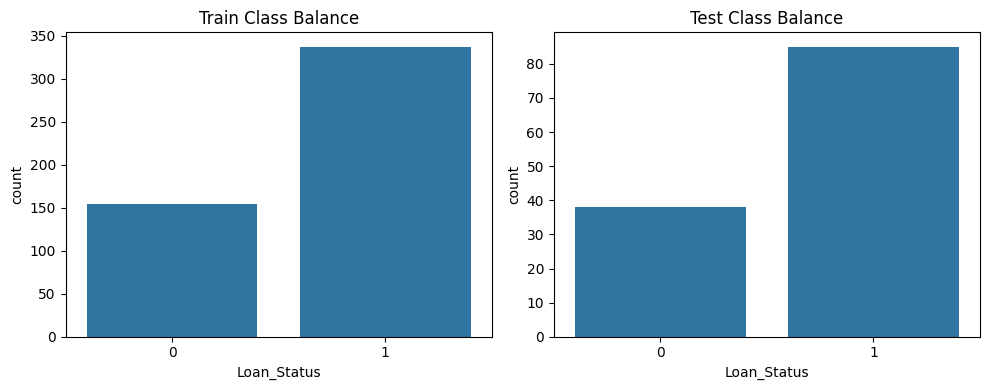

In [ ]:
# Plot class distribution
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(x=y_train, ax=ax[0])
ax[0].set_title('Train Class Balance')
sns.countplot(x=y_test, ax=ax[1])
ax[1].set_title('Test Class Balance')
plt.tight_layout()
plt.show()


In [ ]:
model = CatBoostClassifier(
    iterations=800,
    learning_rate=0.02,
    depth=5,
    l2_leaf_reg=9,
    random_strength=2,
    bootstrap_type='Bernoulli',
    subsample=0.8,
    cat_features=cat_features,
    loss_function='Logloss',
    eval_metric='F1',
    class_weights=[3, 1],
    early_stopping_rounds=50,
    use_best_model=True,
    verbose=100,
    random_seed=42
)

model.fit(X_train, y_train, eval_set=(X_test, y_test))


0:	learn: 0.6354610	test: 0.6375000	best: 0.6375000 (0)	total: 90.2ms	remaining: 1m 12s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7525773196
bestIteration = 14

Shrink model to first 15 iterations.


In [ ]:
y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)
y_proba = model.predict_proba(X_test)[:, 1]

print(f"\n🎯 Training Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"🧪 Testing Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print("✅ F1 Score:", f1_score(y_test, y_pred_test))
print("✅ ROC AUC:", roc_auc_score(y_test, y_proba))
print("\n🔍 Classification Report:\n", classification_report(y_test, y_pred_test))



🎯 Training Accuracy: 0.8045
🧪 Testing Accuracy: 0.8049
✅ F1 Score: 0.8588235294117647
✅ ROC AUC: 0.826625386996904

🔍 Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.68      0.68        38
           1       0.86      0.86      0.86        85

    accuracy                           0.80       123
   macro avg       0.77      0.77      0.77       123
weighted avg       0.80      0.80      0.80       123



In [ ]:
joblib.dump(model, 'catboost_loan_model_regularized_fixed.pkl')
print("📦 Model saved as 'catboost_loan_model_regularized_fixed.pkl'")


📦 Model saved as 'catboost_loan_model_regularized_fixed.pkl'
